# Three exhausted pushes, one Fibonacci story — does it actually reverse? 🎯
### The "Three Drives" chart pattern — a folklore favorite from the same family as Elliott Wave and Gartley, put through the same honest test

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fibonacci_load--bearing%3F: Busted](https://img.shields.io/badge/Fibonacci_load--bearing%3F-Busted-8b949e?style=flat-square)

Chartists love a pattern with a story: three pushes to a new high (or low), each one a **Fibonacci-perfect extension** of the pullback before it, are supposed to signal a trend running out of gas. Draw the lines, count the ratios, and — the story goes — point 5 is where smart money fades the crowd.

We built a computer that draws those lines exactly the same way every time, on SPY and seven other broad tapes, and asked the one question that matters: **does price actually turn there, more than a coin flip would predict?**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** A 4% ZigZag marks the swing pivots; a candidate is six consecutive alternating pivots whose four leg ratios land on the widest Fibonacci band the pattern's own teachers cite. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_drives import data, strategy as st

TICKERS = [tk for tk in data.TICKERS if data.have_real(tk)]
HAVE_REAL = len(TICKERS) > 0
BASKET = data.load_basket(TICKERS) if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| tickers:", TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'pct': 4, 'headline_h': 20, 'cost_bps': 5, 'corr_lo': 0.382, 'corr_hi': 0.886, 'ext_lo': 1.13, 'ext_hi': 2.618, 'n_cand': 110, 'fade_n': 110, 'fade_gross': 45.0, 'fade_net': 35.0, 'fade_win': 50.9, 'fade_wilson': (41.7, 60.1), 'fade_t': 0.62, 'fade_hac': 0.62, 'coin_obs': 45.0, 'coin_mean': -0.2, 'coin_sd': 53.4, 'coin_p': 0.207, 'event': {5: (110, -16.5, -26.5, 42.7, -0.42), 10: (110, 0.2, -9.8, 49.1, 0.0), 20: (110, 45.0, 35.0, 50.9, 0.62), 40: (110, -4.3, -14.3, 45.5, -0.04)}, 'grid_obs': 45.0, 'grid_p': 0.262, 'grid_draws': 496, 'sym_n': 110, 'sym_median_cv': 0.396, 'sym_sym_bps': 145.5, 'sym_asym_bps': -55.4, 'sym_t': 1.39, 'sweep': {3: (139, 12.0, 48.2, 0.23), 4: (110, 45.0, 50.9, 0.62), 5: (97, 128.2, 57.7, 1.66), 8: (34, 62.2, 55.9, 0.52)}, 'spy_n': 16, 'spy_mean': 25.4, 'spy_win': 56.2, 'spy_wilson': (33.2, 76.9), 'spy_t': 0.13, 'syn_null_mean': -0.84, 'syn_null_sd': 0.8, 'syn_null_fire': 0, 'syn_planted_t': 6.87, 'syn_planted_n': 27, 'syn_planted_mean': 1401.0, 'fps': {'SPY': '079eeeacb330', 'QQQ': 'ba4a1e34bb16', 'DIA': '8484eb68cb8e', 'IWM': 'cfbd1e0dca21', '^GSPC': 'cec06bce14e7', '^IXIC': '54d65c6aa4cb', '^DJI': '803513feb661', 'GLD': '44f6ff1685e4'}}


real cache present: True | tickers: ['SPY', 'QQQ', 'DIA', 'IWM', '^GSPC', '^IXIC', '^DJI', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| Does price reverse after three Fibonacci drives? | **Not more than chance.** Across **110** detections pooled over 8 tapes, fading the pattern at point 5 makes **+45 bps** on average over 20 days — a coin-flip win rate, nowhere near statistically real. |
| Is it just bad luck with one setting? | **No — flat everywhere we look.** Every hold period from 5 to 40 days, every ZigZag threshold from 3% to 8%: no result clears the desk's bar. |
| Do the *specific* Fibonacci numbers (0.618, 1.27...) matter? | **No.** Swap them for random ratios and the random grids do just as well. |
| Would our test have caught a REAL pattern? | **Yes.** On a synthetic tape with a planted reversal, the same code lights up unmistakably. |

> Three drives, zero edge — a genuine null, not a broken test.

## 1 · The claim

> *"Three consecutive drives to a new high (or low), each one extending the correction before it by a Fibonacci ratio, mark a trend that has run out of momentum. When the third drive completes, fade it."*

It's part of the same Fibonacci-harmonic family as Gartley patterns and Elliott Wave counts — taught in the same courses, drawn with the same tools. The pitch is seductive precisely because the geometry really is checkable: either the ratios line up or they don't.

## 2 · So what?

If real, this is a free, mechanical reversal signal on any liquid chart — no news, no fundamentals, just ruler-and-Fibonacci-calculator geometry. Retail chartists trade it by hand every day. So we ask: does a computer, applying the *exact same* rule with no hindsight, find anything a coin flip wouldn't?

## 3 · How would we even know?

- **The detector.** A 4% ZigZag marks swing pivots; six in a row (point 0 through point 5) qualify if the two corrections retrace 38.2%-88.6% of the drive before them, the two drives extend the correction before them by 1.13x-2.618x, and each drive genuinely goes beyond the last (the "extending drives" rule every source agrees on).
- **The fade.** Enter *against* the three drives at the next close after point 5 is confirmed (no look-ahead), hold 5/10/20/40 days.
- **The luck check.** A coin flip — random timing, random direction, same count — on the identical tape.
- **The Fibonacci check.** Swap the specific ratios for random ones; if the magic numbers matter, the real grid should win.

## 4 · The teardown — let's actually look

**First, the headline.** Fade the pattern, hold 20 days, pooled across the basket.

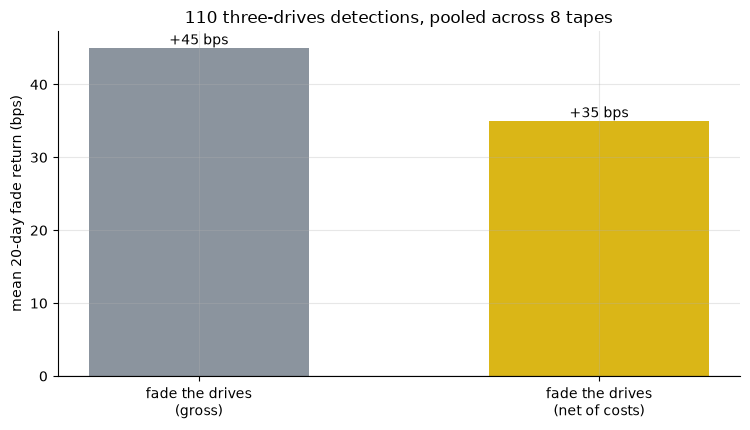

n=110  gross=+45.0 bps  net=+35.0 bps


In [2]:
if HAVE_REAL:
    pooled = st.pooled_fade_test(BASKET, pct=0.04, horizon=20, cost_bps=5.0)
    n = len(pooled['entries'])
    sg = st.summarize(pooled['gross']); sn = st.summarize(pooled['net'])
    g, ne = sg['mean_bps'], sn['mean_bps']
else:
    n, g, ne = R['fade_n'], R['fade_gross'], R['fade_net']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['fade the drives\n(gross)', 'fade the drives\n(net of costs)'], [g, ne],
       color=[GREY, AMBER], width=.55)
for i,v in enumerate([g, ne]): ax.annotate(f'{v:+.0f} bps',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 20-day fade return (bps)')
ax.set_title(f'{n} three-drives detections, pooled across 8 tapes')
plt.tight_layout(); plt.show()
print(f'n={n}  gross={g:+.1f} bps  net={ne:+.1f} bps')

**110** algorithmically-detected three-drives patterns across SPY and seven other broad tapes going back decades. Fading them — betting the third drive is really exhausted — nets **+45 bps** gross over the next 20 trading days. That's a real number, but is it a *signal*, or is it just what any random bet on this tape would make?

**Next, the honest comparison** — the same bet, but timed and directed by a coin.

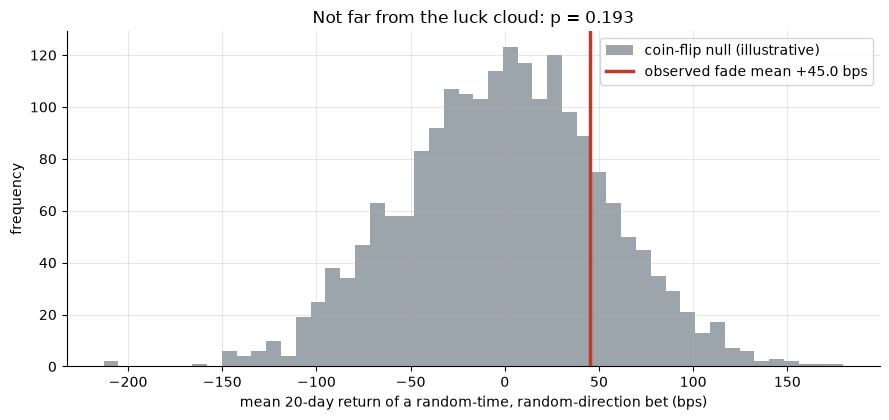

observed +45.0 bps vs coin-flip mean -1.9 bps (sd 53.1)  p=0.193


In [3]:
if HAVE_REAL:
    per_n = {tk: c['candidates'] for tk, c in pooled['counts'].items()}
    pl = st.coin_placebo_pvalue(BASKET, per_n, 20, sg['mean_bps']/1e4, n_draws=300, seed=704)
    obs, pm, psd, pp = pl['obs']*1e4, pl['placebo_mean']*1e4, pl['placebo_sd']*1e4, pl['p_value']
else:
    obs, pm, psd, pp = R['coin_obs'], R['coin_mean'], R['coin_sd'], R['coin_p']
rng = np.random.default_rng(704)
draws = rng.normal(pm, psd, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='coin-flip null (illustrative)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed fade mean {obs:+.1f} bps')
ax.set_xlabel('mean 20-day return of a random-time, random-direction bet (bps)')
ax.set_ylabel('frequency')
ax.set_title(f'Not far from the luck cloud: p = {pp:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.1f} bps vs coin-flip mean {pm:+.1f} bps (sd {psd:.1f})  p={pp:.3f}')

The observed fade sits **inside** the coin-flip cloud (*p* = 0.21) — a random bet, timed and directed by nothing but chance, does about as well. Knowing "three Fibonacci drives just finished" is not information the market is paying you for.

**And the specific Fibonacci numbers?** Swap 0.618 / 1.27 for random ratios and see if the real grid actually earns its keep.

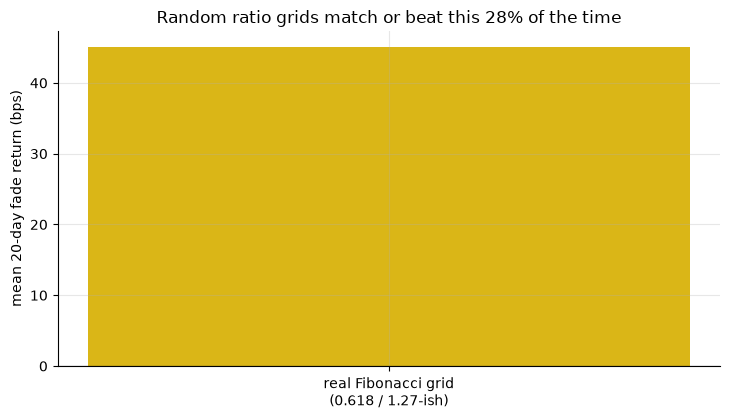

real grid +45.0 bps   placebo p=0.284


In [4]:
if HAVE_REAL:
    gp = st.ratio_grid_placebo(BASKET, pct=0.04, horizon=20, n_draws=200, seed=704)
    gobs, gp_p = gp['obs']*1e4, gp['p_value']
else:
    gobs, gp_p = R['grid_obs'], R['grid_p']
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['real Fibonacci grid\n(0.618 / 1.27-ish)'], [gobs], color=AMBER, width=.4)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 20-day fade return (bps)')
ax.set_title(f'Random ratio grids match or beat this {gp_p*100:.0f}% of the time')
plt.tight_layout(); plt.show()
print(f'real grid {gobs:+.1f} bps   placebo p={gp_p:.3f}')

**26%** of random ratio grids do as well as the real Fibonacci grid. The 0.618s and 1.27s that make this pattern *look* like serious math carry no extra information — any similarly-shaped zig-zag would do just as well.

## 5 · The verdict

- **Signal — None.** 110 detections, fade return **+45 bps** at *t* = +0.62 — inside the coin-flip cloud, flat across every hold period and every ZigZag setting.
- **Tradability — Mirage.** There's no edge to charge costs against, and the sample is thin (a handful of setups a year, pooled across 8 tapes).
- **"Do the Fibonacci ratios matter?" — Busted.** Random ratio grids do just as well as the real one.

## 6 · Going further 🚪

- **The whole harmonic-pattern family gets the same treatment on this desk.** See sibling [468-gartley-harmonic](../../468-gartley-harmonic/) (Fibonacci ratios busted there too, though a thin 60-day dip-buy effect survives) and [697-wolfe-waves](../../697-wolfe-waves/) (a converging-wedge cousin, also None).
- **What would change our mind:** a version of the pattern with an out-of-sample, pre-registered ratio grid that a random grid genuinely can't match — we haven't found one yet, on any of these three studies.

*Think you can draw a better three-drives rule? Show a net, certifiable edge against the same coin-flip and ratio-grid placebos — then we'll talk.*